<a href="https://colab.research.google.com/github/sbrgothub/Turkey_Online_Retail_New/blob/main/Customer_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score

In [ ]:
df=pd.read_csv('/content/drive/MyDrive/luminar/data_science/resume/archive (1)/ecommerce_customer_behavior_dataset_v2.csv')

In [ ]:
df['Date']=pd.to_datetime(df['Date'])

# Analysis 1 :
    Segment customers based on spending,    frequency, and recency

In [ ]:
x={'Customer_ID':[],'Recency':[],'Frequency':[],'Spending':[]}

In [ ]:
for j in set(df['Customer_ID']):
  x['Customer_ID'].append(j)
  x['Frequency'].append(len(df[df['Customer_ID']==j]))
  x['Recency'].append((df['Date'].max()-df[df['Customer_ID']==j]['Date'].max()).days)
  x['Spending'].append(df[df['Customer_ID']==j]['Total_Amount'].mean())

In [ ]:
x=pd.DataFrame(x)

In [ ]:
x_train=x.iloc[:,1:]
x

,Customer_ID,Recency,Frequency,Spending
0,CUST_00910,256,3,341.733333
1,CUST_02842,181,1,3883.350000
2,CUST_03118,97,9,687.058889
3,CUST_04812,70,5,270.122000
4,CUST_01044,268,1,31.710000
...,...,...,...,...
4995,CUST_02105,3,4,1944.510000
4996,CUST_04943,3,8,1490.660000
4997,CUST_04047,68,4,2030.267500
4998,CUST_01150,84,6,858.976667


Clustering Model

In [ ]:
mn=MinMaxScaler()
x_scale=mn.fit_transform(x_train)

In [ ]:
wcss=[]

In [ ]:
for j in range(1,100):
  cluster=KMeans(n_clusters=j,random_state=1)
  cluster.fit(x_scale)
  wcss.append(cluster.inertia_)

Elbow Method to check optimal no of clusters

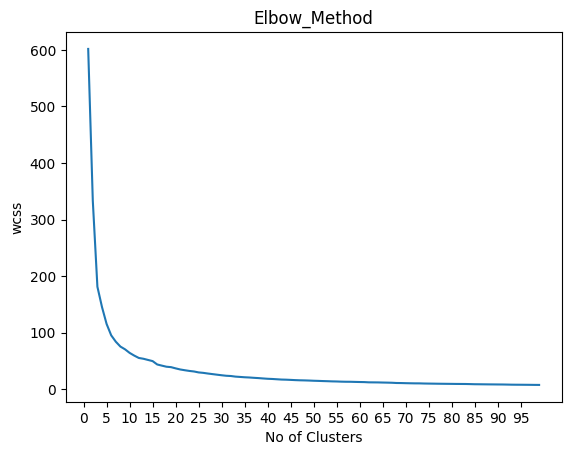

In [ ]:
n_clusters=range(1,100)
plt.plot(n_clusters,wcss)
plt.title('Elbow_Method')
plt.xticks((range(0,100,5)))
plt.xlabel('No of Clusters')
plt.ylabel('wcss')
plt.show()

In [ ]:
op_cl=KMeans(n_clusters=3,random_state=1)
op_cl.fit(x_scale)
print(silhouette_score(x_scale,op_cl.labels_))

0.4417135918120322


In [ ]:
for j in range(2,65):
  op_cl=KMeans(n_clusters=j,random_state=1)
  op_cl.fit(x_scale)
  print(j,silhouette_score(x_scale,op_cl.labels_))

2 0.40219859211282466
3 0.4417135918120322
4 0.352373752770501
5 0.34477042825433746
6 0.37498551801344393
7 0.34891875650055587
8 0.3390710359308393
9 0.3445225779804792
10 0.35048465944007784
11 0.35486187676945347
12 0.3447870353438448
13 0.3271417354969507
14 0.3254921936115114
15 0.34241191043666597
16 0.34283590831864186
17 0.3463292097509468
18 0.34360044510683924
19 0.34282711343018657
20 0.34755408840368757
21 0.3438024095298049
22 0.34295926915610186
23 0.3424071588298678
24 0.3412747242034864
25 0.3502453561840499
26 0.3518725212002884
27 0.3603268400790975
28 0.3637572265895517
29 0.3682573058350072
30 0.3786838813340538
31 0.3838093420564186
32 0.37803461068786937
33 0.3891603263380046
34 0.3905279984539331
35 0.388741271245319
36 0.3859270963955072
37 0.3898883545739232
38 0.3915093070668774
39 0.3966263156355246
40 0.4023438816561391
41 0.39904640214858983
42 0.4033441435403809
43 0.406654648801325
44 0.40707697715046093
45 0.40776311382066865
46 0.40647846795626463
47 0

In [ ]:
op_cl=KMeans(n_clusters=3,random_state=1)
op_cl.fit(x_scale)

KMeans(n_clusters=3, random_state=1)

In [ ]:
op_cl.labels_

array([2, 2, 1, ..., 0, 1, 0], dtype=int32)

In [ ]:
x['Cluster']=op_cl.labels_

In [ ]:
for j in (0,1,2):
  print(x[x['Cluster']==j].describe())
  print('_+'*40)

           Recency    Frequency      Spending  Cluster
count  2491.000000  2491.000000   2491.000000   2491.0
mean     78.962264     2.604175   1242.568557      0.0
std      51.091014     0.977604   1587.500446      0.0
min       0.000000     1.000000     14.810000      0.0
25%      35.000000     2.000000    343.419167      0.0
50%      74.000000     3.000000    747.840000      0.0
75%     119.000000     3.000000   1514.960833      0.0
max     197.000000     4.000000  25314.075000      0.0
_+_+_+_+_+_+_+_+_+_+_+_+_+_+_+_+_+_+_+_+_+_+_+_+_+_+_+_+_+_+_+_+_+_+_+_+_+_+_+_+
           Recency    Frequency     Spending  Cluster
count  1253.000000  1253.000000  1253.000000   1253.0
mean     57.790104     6.572227  1285.645845      1.0
std      49.753464     1.591389   941.602199      0.0
min       0.000000     5.000000   113.907143      1.0
25%      17.000000     5.000000   629.846000      1.0
50%      45.000000     6.000000  1046.441111      1.0
75%      85.000000     8.000000  1619.706000  